# Regularization, Validation Sets, and Cross Validation

This notebook builds a small experiment around a system whose measurements come from an unknown cubic relationship plus noise. We pretend the true governing equation is hidden from us, then fit polynomial hypotheses up to degree 10.

The goal is to see how regularization and validation strategies help us answer two practical questions:

- Is a flexible polynomial model overfitting the training data?
- Which value of `lambda1` $\lambda_1$ or `lambda2` $\lambda_2$ should we choose for a regression model?

We will use these regularization terms:

```text
training objective = mean squared error + lambda1 * sum(abs(coefficients)) + lambda2 * sum(coefficients^2)
```

Interpretation:

- `lambda1` encourages sparsity. This is the LASSO idea.
- `lambda2` shrinks coefficient sizes smoothly. This is the Ridge idea.
- using both gives Elastic Net style behavior.

The intercept is not regularized.

This notebook uses three kinds of data splits:

- training set: used to fit the model coefficients,
- validation set: used to identify overfitting and choose a regularization strength,
- testing set: held back until the end as a final estimate of performance.

## 0. One-Time Setup

If the import cell below says `ipywidgets` is missing, run this installation cell once. Then restart the notebook kernel and run from the top.

In [1]:
# Optional: run once if needed, then restart the kernel.
# %pip install -r requirements.txt

## 1. Imports

In [2]:
import os
from pathlib import Path

# Keeps matplotlib from trying to write cache files into a restricted home folder.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

try:
    from IPython.display import display
except ImportError:
    display = print

try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print("ipywidgets is not installed yet. Run the setup cell above, restart the kernel, and rerun this notebook.")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 2. Create Noisy Data From an Unknown Cubic System

For teaching purposes, we know the data came from a cubic function plus noise. The model does not receive that fact. It only sees measured points and has to choose a polynomial hypothesis from degrees 1 through 10.

We will split the measured data into three groups:

- a training set to fit model coefficients,
- a validation set to choose the polynomial degree and regularization strength,
- a testing set for the final check after the model choice has already been made.

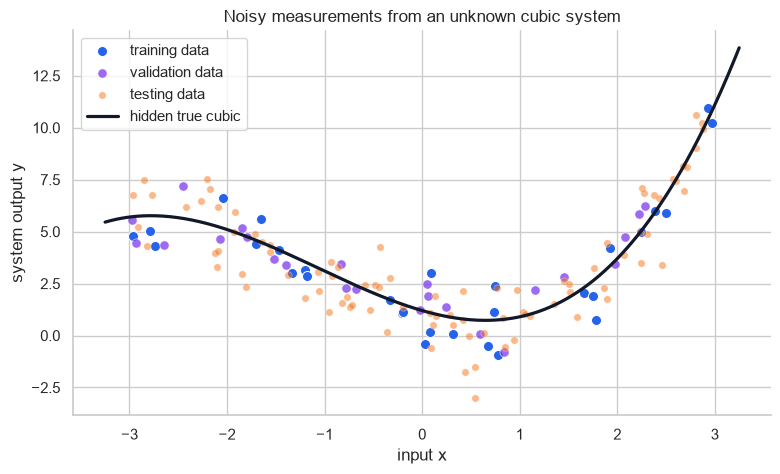

In [3]:
RANDOM_SEED = 7
MAX_HYPOTHESIS_DEGREE = 10
rng = np.random.default_rng(RANDOM_SEED)

# Hidden system. Students should imagine this is unknown during modeling.
def hidden_cubic_system(x):
    return 0.25 * x**3 + 0.80 * x**2 - 1.35 * x + 1.20

# Here, the training/validation/testing split is exaggurated for demonstration purposes.
n_train = 30 
n_validation = 24
n_test = 90
noise_std = 1.15

x_train = np.sort(rng.uniform(-3.0, 3.0, size=n_train))
x_validation = np.sort(rng.uniform(-3.0, 3.0, size=n_validation))
x_test = np.sort(rng.uniform(-3.0, 3.0, size=n_test))

y_train_clean = hidden_cubic_system(x_train)
y_validation_clean = hidden_cubic_system(x_validation)
y_test_clean = hidden_cubic_system(x_test)

y_train = y_train_clean + rng.normal(0, noise_std, size=n_train)
y_validation = y_validation_clean + rng.normal(0, noise_std, size=n_validation)
y_test = y_test_clean + rng.normal(0, noise_std, size=n_test)

x_grid = np.linspace(-3.25, 3.25, 350)
y_grid_true = hidden_cubic_system(x_grid)

X_train = x_train.reshape(-1, 1)
X_validation = x_validation.reshape(-1, 1)
X_test = x_test.reshape(-1, 1)
X_grid = x_grid.reshape(-1, 1)

# Cross validation will use the data that would normally be available before the final test.
X_model_selection = np.vstack([X_train, X_validation])
y_model_selection = np.concatenate([y_train, y_validation])

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x_train, y_train, s=52, label="training data", color="#2563eb", edgecolor="white", linewidth=0.7)
ax.scatter(x_validation, y_validation, s=44, label="validation data", color="#7c3aed", alpha=0.75, edgecolor="white", linewidth=0.5)
ax.scatter(x_test, y_test, s=28, label="testing data", color="#f97316", alpha=0.50, edgecolor="white", linewidth=0.4)
ax.plot(x_grid, y_grid_true, color="#111827", linewidth=2.3, label="hidden true cubic")
ax.set_title("Noisy measurements from an unknown cubic system")
ax.set_xlabel("input x")
ax.set_ylabel("system output y")
ax.legend(loc="best")
plt.show()

## 3. Modeling Utilities

Each model uses polynomial features up to a chosen degree. The polynomial columns are standardized before regularization so that high-power terms are not unfairly penalized only because of their scale.

In [4]:
def build_model(method, lambda1=0.0, lambda2=0.0):
    """Return the regression estimator for the selected regularization method."""
    method = method.lower()

    if method == "ordinary least squares":
        return LinearRegression()

    if method == "ridge":
        if float(lambda2) <= 0:
            return LinearRegression()
        return Ridge(alpha=float(lambda2), random_state=RANDOM_SEED)

    if method == "lasso":
        if float(lambda1) <= 0:
            return LinearRegression()
        return Lasso(alpha=float(lambda1), max_iter=50_000, random_state=RANDOM_SEED)

    if method == "elastic net":
        lambda1 = float(lambda1)
        lambda2 = float(lambda2)
        combined = lambda1 + lambda2
        if combined == 0:
            return LinearRegression()
        l1_ratio = lambda1 / combined
        return ElasticNet(
            alpha=combined,
            l1_ratio=l1_ratio,
            max_iter=80_000,
            random_state=RANDOM_SEED,
        )

    raise ValueError(f"Unknown method: {method}")


def make_polynomial_pipeline(degree, method, lambda1=0.0, lambda2=0.0):
    return make_pipeline(
        PolynomialFeatures(degree=int(degree), include_bias=False),
        StandardScaler(),
        build_model(method, lambda1=lambda1, lambda2=lambda2),
    )


def fit_polynomial_model(degree, method, lambda1=0.0, lambda2=0.0):
    """Fit a polynomial model and return predictions, coefficients, and losses."""
    model = make_polynomial_pipeline(degree, method, lambda1=lambda1, lambda2=lambda2)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        model.fit(X_train, y_train)

    yhat_train = model.predict(X_train)
    yhat_validation = model.predict(X_validation)
    yhat_test = model.predict(X_test)
    yhat_grid = model.predict(X_grid)

    estimator = model.named_steps[list(model.named_steps.keys())[-1]]
    coefficients = getattr(estimator, "coef_", np.zeros(degree))
    coefficients = np.asarray(coefficients).ravel()

    train_mse = mean_squared_error(y_train, yhat_train)
    validation_mse = mean_squared_error(y_validation, yhat_validation)
    test_mse = mean_squared_error(y_test, yhat_test)
    l1_penalty = float(lambda1) * np.sum(np.abs(coefficients))
    l2_penalty = float(lambda2) * np.sum(coefficients**2)
    total_train_objective = train_mse + l1_penalty + l2_penalty

    return {
        "model": model,
        "yhat_train": yhat_train,
        "yhat_validation": yhat_validation,
        "yhat_test": yhat_test,
        "yhat_grid": yhat_grid,
        "coefficients": coefficients,
        "train_mse": train_mse,
        "validation_mse": validation_mse,
        "test_mse": test_mse,
        "l1_penalty": l1_penalty,
        "l2_penalty": l2_penalty,
        "total_train_objective": total_train_objective,
        "nonzero_coefficients": int(np.sum(np.abs(coefficients) > 1e-6)),
    }


def cross_validate_polynomial_model(degree, method, lambda1=0.0, lambda2=0.0, n_splits=5):
    """Estimate out-of-sample error by rotating which fold acts like the validation set."""
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    fold_mse_values = []

    for train_index, validation_index in kfold.split(X_model_selection):
        X_fold_train = X_model_selection[train_index]
        y_fold_train = y_model_selection[train_index]
        X_fold_validation = X_model_selection[validation_index]
        y_fold_validation = y_model_selection[validation_index]

        model = make_polynomial_pipeline(degree, method, lambda1=lambda1, lambda2=lambda2)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            model.fit(X_fold_train, y_fold_train)

        yhat_fold_validation = model.predict(X_fold_validation)
        fold_mse_values.append(mean_squared_error(y_fold_validation, yhat_fold_validation))

    fold_mse_values = np.array(fold_mse_values)
    return {
        "cv_mean_mse": fold_mse_values.mean(),
        "cv_std_mse": fold_mse_values.std(ddof=1),
        "fold_mse_values": fold_mse_values,
    }


def coefficient_table(coefficients):
    return pd.DataFrame({
        "polynomial term": [f"x^{i}" for i in range(1, len(coefficients) + 1)],
        "coefficient after scaling": coefficients,
        "absolute value": np.abs(coefficients),
    })

## 4. Compare Polynomial Degrees Without Regularization

This first table shows why regularization is useful. As the polynomial degree increases up to 10, the training error can keep dropping while the testing error may get worse.

,method,degree,lambda1,lambda2,train_mse,validation_mse,test_mse,total_train_objective,nonzero_coefficients
0,ordinary least squares,1,0.000000,0.000000,7.949,4.236,7.983,7.949,1
1,ordinary least squares,2,0.000000,0.000000,2.697,1.890,2.258,2.697,2
2,ordinary least squares,3,0.000000,0.000000,0.855,0.927,1.521,0.855,3
3,ordinary least squares,4,0.000000,0.000000,0.837,0.905,1.522,0.837,4
4,ordinary least squares,5,0.000000,0.000000,0.814,0.979,1.535,0.814,5
5,ordinary least squares,6,0.000000,0.000000,0.808,0.987,1.537,0.808,6
6,ordinary least squares,7,0.000000,0.000000,0.775,1.044,1.628,0.775,7
7,ordinary least squares,8,0.000000,0.000000,0.718,1.065,1.768,0.718,8
8,ordinary least squares,9,0.000000,0.000000,0.716,1.043,1.741,0.716,9
9,ordinary least squares,10,0.000000,0.000000,0.714,1.009,1.760,0.714,10


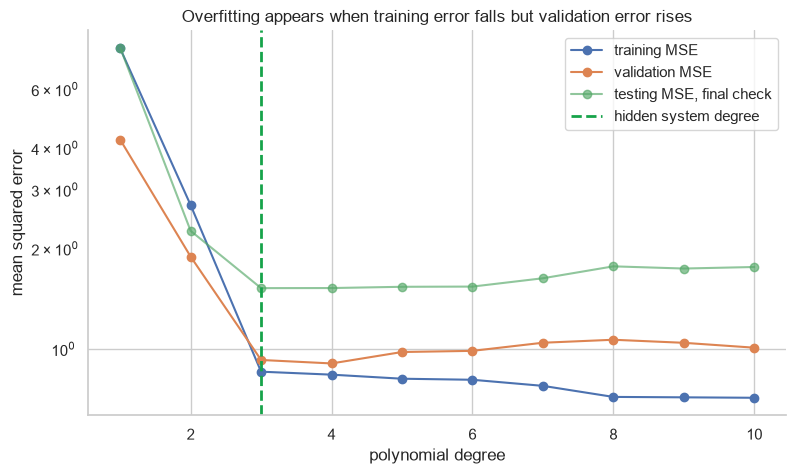

In [5]:
def summarize_degrees(method="ordinary least squares", lambda1=0.0, lambda2=0.0, degrees=range(1, MAX_HYPOTHESIS_DEGREE + 1)):
    rows = []
    for degree in degrees:
        result = fit_polynomial_model(degree, method, lambda1=lambda1, lambda2=lambda2)
        rows.append({
            "method": method,
            "degree": degree,
            "lambda1": lambda1,
            "lambda2": lambda2,
            "train_mse": result["train_mse"],
            "validation_mse": result["validation_mse"],
            "test_mse": result["test_mse"],
            "total_train_objective": result["total_train_objective"],
            "nonzero_coefficients": result["nonzero_coefficients"],
        })
    return pd.DataFrame(rows)

ols_degree_summary = summarize_degrees()
display(ols_degree_summary.style.format({
    "train_mse": "{:.3f}",
    "validation_mse": "{:.3f}",
    "test_mse": "{:.3f}",
    "total_train_objective": "{:.3f}",
}))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ols_degree_summary["degree"], ols_degree_summary["train_mse"], marker="o", label="training MSE")
ax.plot(ols_degree_summary["degree"], ols_degree_summary["validation_mse"], marker="o", label="validation MSE")
ax.plot(ols_degree_summary["degree"], ols_degree_summary["test_mse"], marker="o", alpha=0.65, label="testing MSE, final check")
ax.axvline(3, color="#16a34a", linestyle="--", linewidth=2, label="hidden system degree")
ax.set_title("Overfitting appears when training error falls but validation error rises")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("mean squared error")
ax.set_yscale("log")
ax.legend()
plt.show()

## 5. Training Loss Heatmaps for Ridge and LASSO

These heatmaps show the regularized training objective for polynomial degrees 1 through 10 and many regularization strengths.

- Ridge changes `lambda2` and keeps `lambda1 = 0`.
- LASSO changes `lambda1` and keeps `lambda2 = 0`.

The color scale uses `log10(loss)` so both small and large changes are visible.

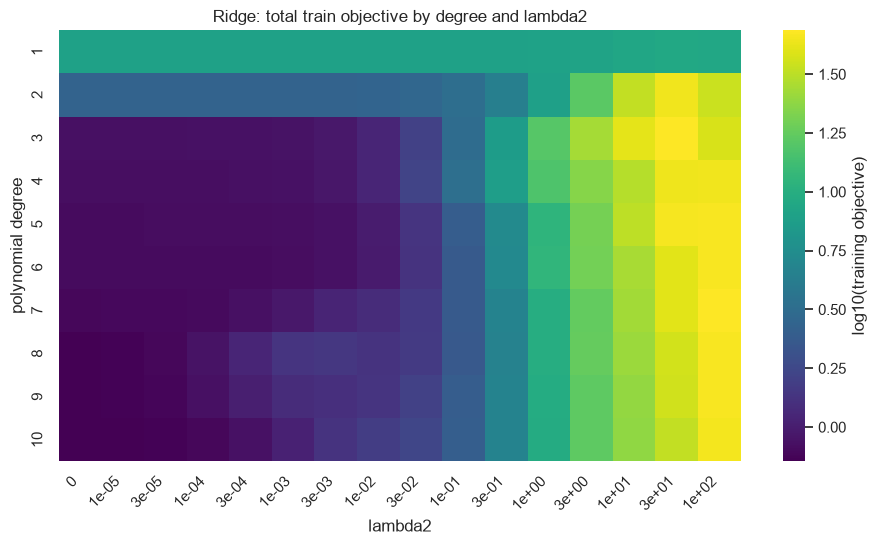

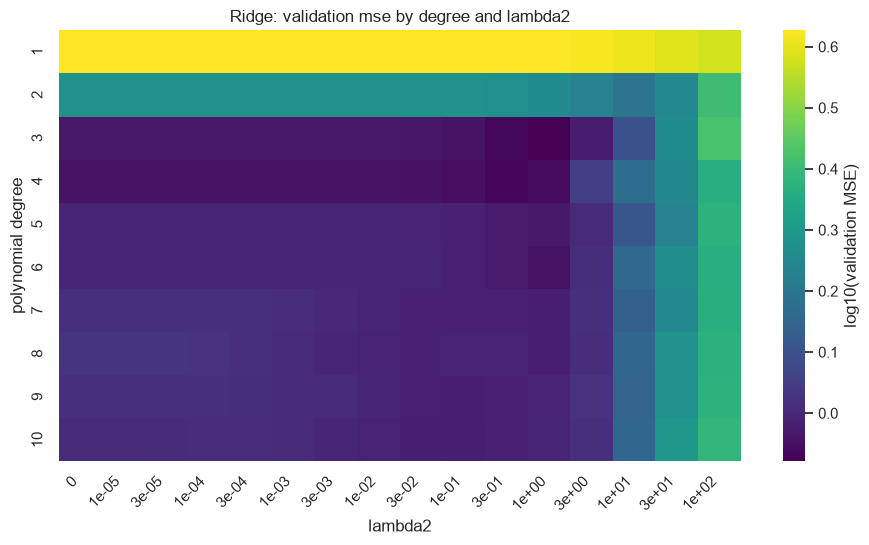

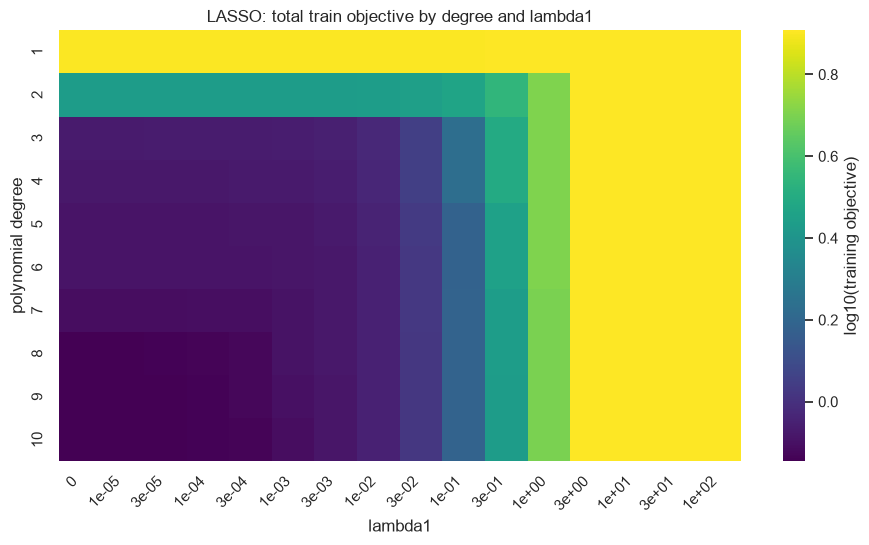

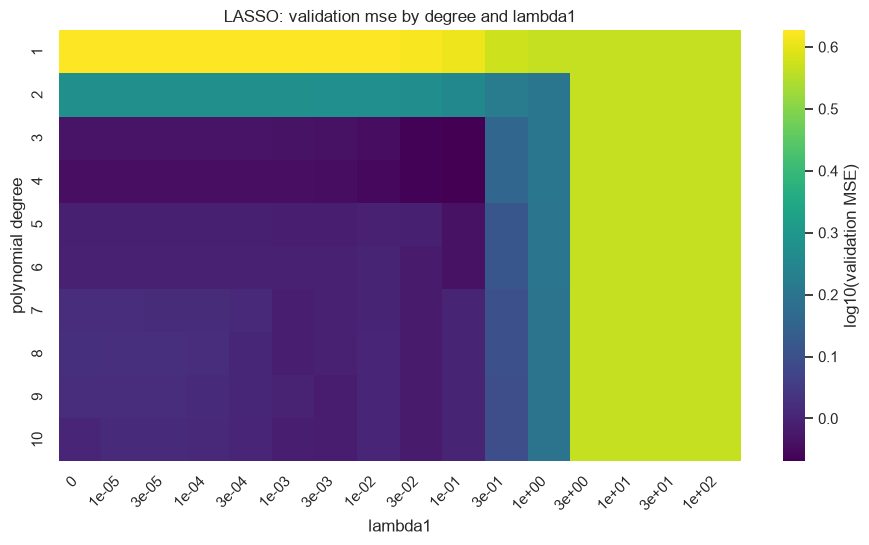

In [6]:
def one_lambda_loss_grid(method, lambda_values, degrees=range(1, MAX_HYPOTHESIS_DEGREE + 1)):
    rows = []
    for degree in degrees:
        for lam in lambda_values:
            if method.lower() == "ridge":
                result = fit_polynomial_model(degree, method, lambda1=0.0, lambda2=lam)
                lambda1, lambda2 = 0.0, lam
            elif method.lower() == "lasso":
                result = fit_polynomial_model(degree, method, lambda1=lam, lambda2=0.0)
                lambda1, lambda2 = lam, 0.0
            else:
                raise ValueError("Use this helper for Ridge or LASSO.")

            rows.append({
                "method": method,
                "degree": degree,
                "lambda": lam,
                "lambda1": lambda1,
                "lambda2": lambda2,
                "train_mse": result["train_mse"],
                "validation_mse": result["validation_mse"],
                "test_mse": result["test_mse"],
                "total_train_objective": result["total_train_objective"],
                "nonzero_coefficients": result["nonzero_coefficients"],
            })
    return pd.DataFrame(rows)

lambda_values = np.r_[0.0, np.logspace(-5, 2, 15)]
ridge_grid = one_lambda_loss_grid("Ridge", lambda_values)
lasso_grid = one_lambda_loss_grid("LASSO", lambda_values)

def plot_one_lambda_heatmap(grid, method, lambda_label, value_column, colorbar_label):
    heatmap_data = grid.pivot(index="degree", columns="lambda", values=value_column)
    safe_values = np.log10(heatmap_data + 1e-9)

    fig, ax = plt.subplots(figsize=(11, 5.6))
    sns.heatmap(safe_values, cmap="viridis", ax=ax, cbar_kws={"label": colorbar_label})
    ax.set_title(f"{method}: {value_column.replace('_', ' ')} by degree and {lambda_label}")
    ax.set_xlabel(lambda_label)
    ax.set_ylabel("polynomial degree")
    ax.set_xticklabels([f"{v:.0e}" if v > 0 else "0" for v in heatmap_data.columns], rotation=45, ha="right")
    plt.show()

plot_one_lambda_heatmap(ridge_grid, "Ridge", "lambda2", "total_train_objective", "log10(training objective)")
plot_one_lambda_heatmap(ridge_grid, "Ridge", "lambda2", "validation_mse", "log10(validation MSE)")
plot_one_lambda_heatmap(lasso_grid, "LASSO", "lambda1", "total_train_objective", "log10(training objective)")
plot_one_lambda_heatmap(lasso_grid, "LASSO", "lambda1", "validation_mse", "log10(validation MSE)")

## 6. Elastic Net: Training and Validation Loss Over Both lambda1 and lambda2

Elastic Net uses both terms at once. The next plots fix the hypothesis at degree 10 and vary both `lambda1` and `lambda2`.

The training objective tells us what the optimizer is directly minimizing. The validation MSE helps us choose regularization strengths that are more likely to generalize.

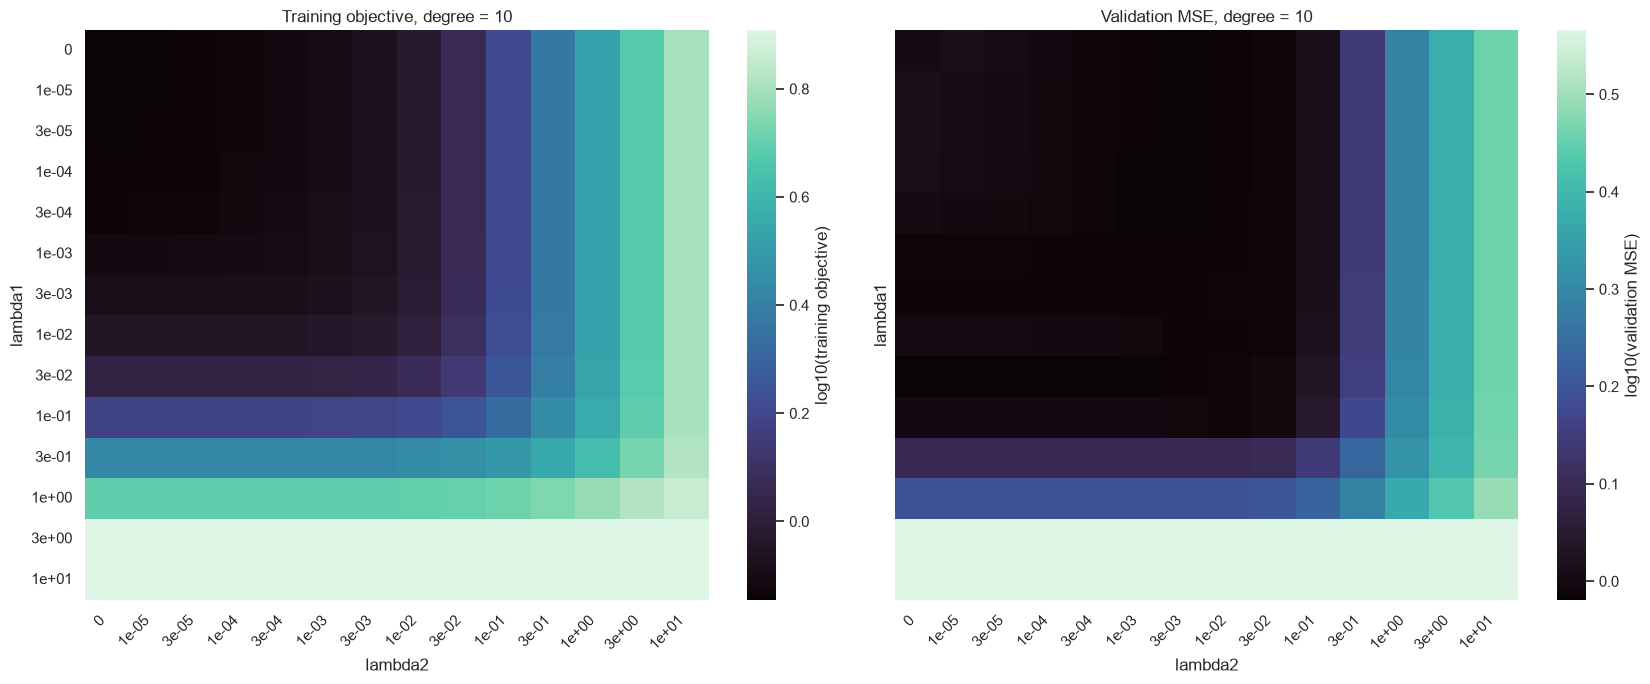

In [7]:
def elastic_net_loss_grid(degree=MAX_HYPOTHESIS_DEGREE, lambda1_values=None, lambda2_values=None):
    if lambda1_values is None:
        lambda1_values = np.r_[0.0, np.logspace(-5, 1, 13)]
    if lambda2_values is None:
        lambda2_values = np.r_[0.0, np.logspace(-5, 1, 13)]

    rows = []
    for lambda1 in lambda1_values:
        for lambda2 in lambda2_values:
            result = fit_polynomial_model(degree, "Elastic Net", lambda1=lambda1, lambda2=lambda2)
            rows.append({
                "degree": degree,
                "lambda1": lambda1,
                "lambda2": lambda2,
                "train_mse": result["train_mse"],
                "validation_mse": result["validation_mse"],
                "test_mse": result["test_mse"],
                "total_train_objective": result["total_train_objective"],
                "nonzero_coefficients": result["nonzero_coefficients"],
            })
    return pd.DataFrame(rows)

elastic_grid = elastic_net_loss_grid(degree=MAX_HYPOTHESIS_DEGREE)
training_heatmap = elastic_grid.pivot(index="lambda1", columns="lambda2", values="total_train_objective")
validation_heatmap = elastic_grid.pivot(index="lambda1", columns="lambda2", values="validation_mse")

fig, axes = plt.subplots(1, 2, figsize=(17, 7), sharey=True)

sns.heatmap(
    np.log10(training_heatmap + 1e-9),
    cmap="mako",
    ax=axes[0],
    cbar_kws={"label": "log10(training objective)"},
)
axes[0].set_title(f"Training objective, degree = {MAX_HYPOTHESIS_DEGREE}")
axes[0].set_xlabel("lambda2")
axes[0].set_ylabel("lambda1")

sns.heatmap(
    np.log10(validation_heatmap + 1e-9),
    cmap="mako",
    ax=axes[1],
    cbar_kws={"label": "log10(validation MSE)"},
)
axes[1].set_title(f"Validation MSE, degree = {MAX_HYPOTHESIS_DEGREE}")
axes[1].set_xlabel("lambda2")
axes[1].set_ylabel("lambda1")

for ax, heatmap_data in zip(axes, [training_heatmap, validation_heatmap]):
    ax.set_xticklabels([f"{v:.0e}" if v > 0 else "0" for v in heatmap_data.columns], rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.0e}" if v > 0 else "0" for v in heatmap_data.index], rotation=0)

plt.tight_layout()
plt.show()

## 7. Interactive Slider: Fit, Loss, and Coefficients

Use the sliders to change the polynomial degree, method, `lambda1`, and `lambda2`.

Suggested experiments:

- Set the degree to 10, then increase `lambda2` for Ridge.
- Set the degree to 10, then increase `lambda1` for LASSO.
- Use Elastic Net and change both sliders.
- Compare degree 3 and degree 10. The true system is cubic, but the model does not know that.
- Watch the testing error. A lower training error is not automatically a better hypothesis.

In [8]:
def plot_interactive_regularization(degree=MAX_HYPOTHESIS_DEGREE, method="Elastic Net", lambda1=0.001, lambda2=0.001):
    if method == "Ridge":
        lambda1_used = 0.0
        lambda2_used = lambda2
    elif method == "LASSO":
        lambda1_used = lambda1
        lambda2_used = 0.0
    elif method == "Ordinary Least Squares":
        lambda1_used = 0.0
        lambda2_used = 0.0
    else:
        lambda1_used = lambda1
        lambda2_used = lambda2

    result = fit_polynomial_model(degree, method, lambda1=lambda1_used, lambda2=lambda2_used)
    coefficients = result["coefficients"]

    fig = plt.figure(figsize=(15, 9))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.25, 1.0])

    ax_fit = fig.add_subplot(gs[0, :])
    ax_fit.scatter(x_train, y_train, s=58, color="#2563eb", edgecolor="white", linewidth=0.7, label="training data")
    ax_fit.scatter(x_validation, y_validation, s=44, color="#7c3aed", alpha=0.75, edgecolor="white", linewidth=0.5, label="validation data")
    ax_fit.scatter(x_test, y_test, s=28, color="#f97316", alpha=0.50, edgecolor="white", linewidth=0.4, label="testing data")
    ax_fit.plot(x_grid, y_grid_true, color="#111827", linewidth=2.2, linestyle="--", label="hidden true cubic")
    ax_fit.plot(x_grid, result["yhat_grid"], color="#16a34a", linewidth=2.6, label="learned hypothesis")
    ax_fit.set_title(f"{method}, degree {degree}, lambda1 = {lambda1_used:.2e}, lambda2 = {lambda2_used:.2e}")
    ax_fit.set_xlabel("input x")
    ax_fit.set_ylabel("system output y")
    ax_fit.legend(loc="best", ncol=2)

    ax_loss = fig.add_subplot(gs[1, 0])
    labels = ["train MSE", "validation MSE", "test MSE", "lambda1 term", "lambda2 term", "total train objective"]
    values = [
        result["train_mse"],
        result["validation_mse"],
        result["test_mse"],
        result["l1_penalty"],
        result["l2_penalty"],
        result["total_train_objective"],
    ]
    colors = ["#2563eb", "#7c3aed", "#f97316", "#dc2626", "#0891b2", "#111827"]
    ax_loss.bar(labels, values, color=colors)
    ax_loss.set_yscale("log")
    ax_loss.set_title("Loss pieces")
    ax_loss.set_ylabel("value, log scale")
    ax_loss.tick_params(axis="x", rotation=25)

    ax_coef = fig.add_subplot(gs[1, 1])
    powers = np.arange(1, len(coefficients) + 1)
    markerline, stemlines, baseline = ax_coef.stem(powers, coefficients, basefmt=" ")
    plt.setp(markerline, marker="o", markersize=6, markerfacecolor="#0f766e", markeredgecolor="white")
    plt.setp(stemlines, color="#0f766e", linewidth=1.6)
    ax_coef.axhline(0, color="#111827", linewidth=1)
    ax_coef.set_title(f"Polynomial coefficients after scaling ({result['nonzero_coefficients']} nonzero)")
    ax_coef.set_xlabel("polynomial power")
    ax_coef.set_ylabel("coefficient")
    ax_coef.set_xticks(powers)

    plt.tight_layout()
    plt.show()

    display(pd.DataFrame({
        "quantity": ["train MSE", "validation MSE", "test MSE", "lambda1 penalty", "lambda2 penalty", "total training objective", "nonzero coefficients"],
        "value": [
            result["train_mse"],
            result["validation_mse"],
            result["test_mse"],
            result["l1_penalty"],
            result["l2_penalty"],
            result["total_train_objective"],
            result["nonzero_coefficients"],
        ],
    }).style.format({"value": "{:.4g}"}))

if HAS_WIDGETS:
    controls = widgets.interactive(
        plot_interactive_regularization,
        degree=widgets.IntSlider(value=MAX_HYPOTHESIS_DEGREE, min=1, max=MAX_HYPOTHESIS_DEGREE, step=1, description="degree", continuous_update=False),
        method=widgets.Dropdown(
            options=["Ordinary Least Squares", "Ridge", "LASSO", "Elastic Net"],
            value="Elastic Net",
            description="method",
        ),
        lambda1=widgets.FloatLogSlider(
            value=1e-3, base=10, min=-6, max=2, step=0.25,
            description="lambda1", continuous_update=False, readout_format=".1e",
        ),
        lambda2=widgets.FloatLogSlider(
            value=1e-3, base=10, min=-6, max=2, step=0.25,
            description="lambda2", continuous_update=False, readout_format=".1e",
        ),
    )
    display(controls)
else:
    plot_interactive_regularization(degree=MAX_HYPOTHESIS_DEGREE, method="Elastic Net", lambda1=1e-3, lambda2=1e-3)

interactive(children=(IntSlider(value=10, continuous_update=False, description='degree', max=10, min=1), Dropd…

## 8. Heatmap: Effect of lambda2 on Ridge Coefficients

Ridge regularization does not usually set coefficients exactly to zero. Instead, increasing `lambda2` smoothly shrinks coefficients toward zero. This heatmap fixes the hypothesis at degree 10 and varies `lambda2`.

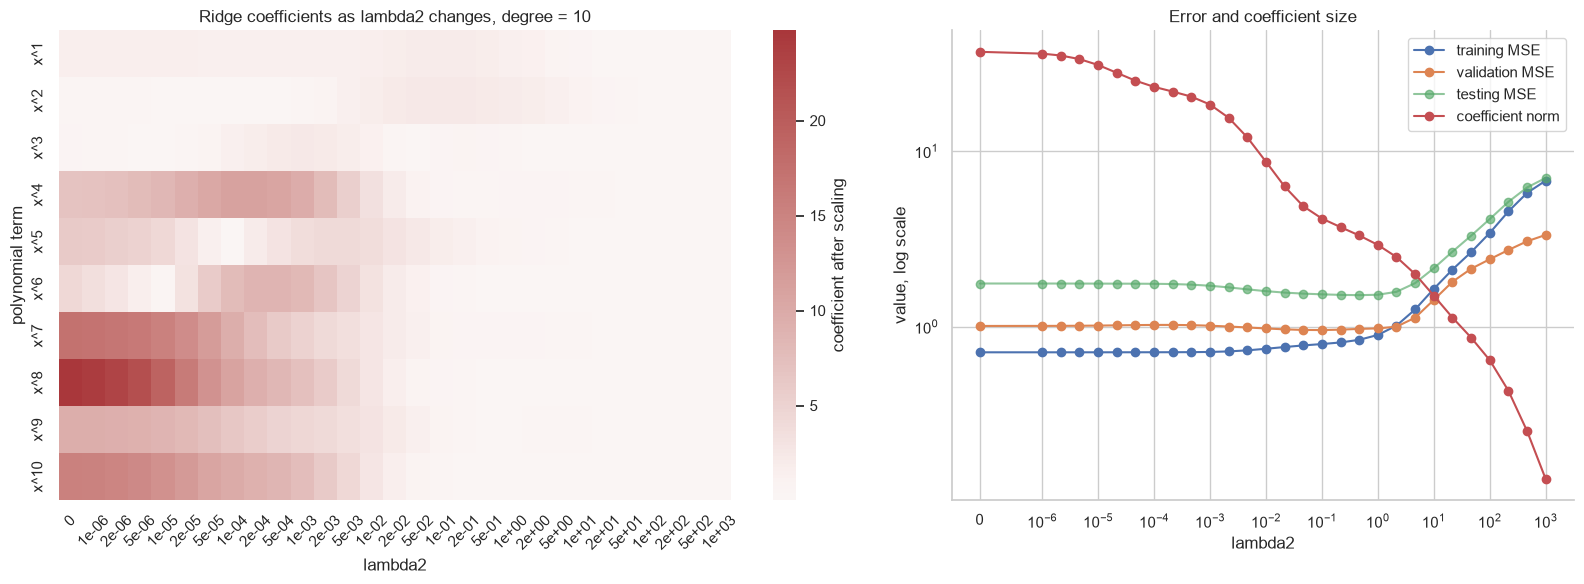

In [9]:
def ridge_coefficient_heatmap(degree=MAX_HYPOTHESIS_DEGREE, lambda2_values=None):
    if lambda2_values is None:
        lambda2_values = np.r_[0.0, np.logspace(-6, 3, 28)]

    coefficient_rows = []
    summary_rows = []
    for lambda2 in lambda2_values:
        result = fit_polynomial_model(degree, "Ridge", lambda1=0.0, lambda2=lambda2)
        coefficient_rows.append(result["coefficients"])
        summary_rows.append({
            "lambda2": lambda2,
            "train_mse": result["train_mse"],
            "validation_mse": result["validation_mse"],
            "test_mse": result["test_mse"],
            "coefficient_norm": np.linalg.norm(result["coefficients"]),
        })

    coefficient_matrix = np.array(coefficient_rows).T
    coefficient_df = pd.DataFrame(
        coefficient_matrix,
        index=[f"x^{i}" for i in range(1, degree + 1)],
        columns=[f"{v:.0e}" if v > 0 else "0" for v in lambda2_values],
    )
    summary_df = pd.DataFrame(summary_rows)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.35, 1.0]})

    sns.heatmap(
        np.abs(coefficient_df),
        cmap="vlag",
        center=0,
        ax=axes[0],
        cbar_kws={"label": "coefficient after scaling"},
    )
    axes[0].set_title(f"Ridge coefficients as lambda2 changes, degree = {degree}")
    axes[0].set_xlabel("lambda2")
    axes[0].set_ylabel("polynomial term")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].plot(summary_df["lambda2"], summary_df["train_mse"], marker="o", label="training MSE")
    axes[1].plot(summary_df["lambda2"], summary_df["validation_mse"], marker="o", label="validation MSE")
    axes[1].plot(summary_df["lambda2"], summary_df["test_mse"], marker="o", alpha=0.65, label="testing MSE")
    axes[1].plot(summary_df["lambda2"], summary_df["coefficient_norm"], marker="o", label="coefficient norm")
    axes[1].set_xscale("symlog", linthresh=1e-6)
    axes[1].set_yscale("log")
    axes[1].set_title("Error and coefficient size")
    axes[1].set_xlabel("lambda2")
    axes[1].set_ylabel("value, log scale")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

ridge_coefficient_heatmap(degree=MAX_HYPOTHESIS_DEGREE)

## 9. LASSO Coefficients: Sparsity From lambda1

For comparison, this plot varies `lambda1` for a degree 10 LASSO model. Large enough values can set some coefficients exactly to zero.

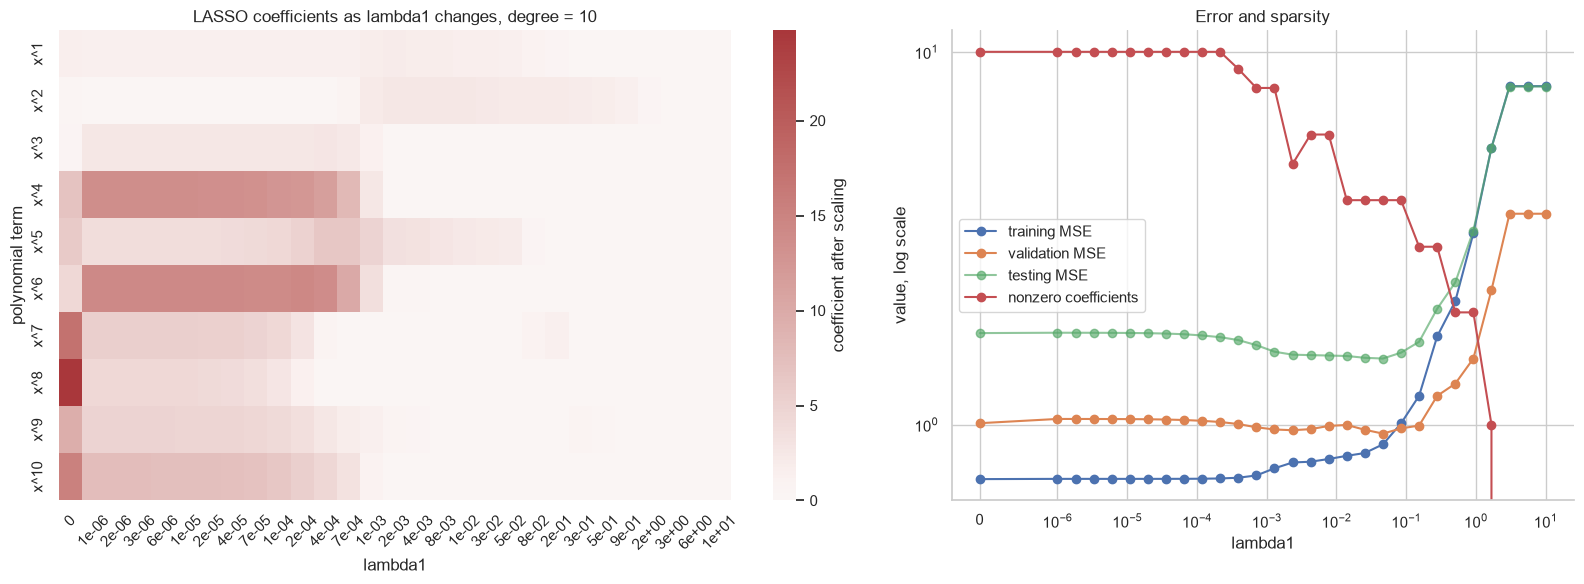

In [10]:
def lasso_coefficient_heatmap(degree=MAX_HYPOTHESIS_DEGREE, lambda1_values=None):
    if lambda1_values is None:
        lambda1_values = np.r_[0.0, np.logspace(-6, 1, 28)]

    coefficient_rows = []
    summary_rows = []
    for lambda1 in lambda1_values:
        result = fit_polynomial_model(degree, "LASSO", lambda1=lambda1, lambda2=0.0)
        coefficient_rows.append(result["coefficients"])
        summary_rows.append({
            "lambda1": lambda1,
            "train_mse": result["train_mse"],
            "validation_mse": result["validation_mse"],
            "test_mse": result["test_mse"],
            "nonzero_coefficients": result["nonzero_coefficients"],
        })

    coefficient_matrix = np.array(coefficient_rows).T
    coefficient_df = pd.DataFrame(
        coefficient_matrix,
        index=[f"x^{i}" for i in range(1, degree + 1)],
        columns=[f"{v:.0e}" if v > 0 else "0" for v in lambda1_values],
    )
    summary_df = pd.DataFrame(summary_rows)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.35, 1.0]})

    sns.heatmap(
        np.abs(coefficient_df),
        cmap="vlag",
        center=0,
        ax=axes[0],
        cbar_kws={"label": "coefficient after scaling"},
    )
    axes[0].set_title(f"LASSO coefficients as lambda1 changes, degree = {degree}")
    axes[0].set_xlabel("lambda1")
    axes[0].set_ylabel("polynomial term")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].plot(summary_df["lambda1"], summary_df["train_mse"], marker="o", label="training MSE")
    axes[1].plot(summary_df["lambda1"], summary_df["validation_mse"], marker="o", label="validation MSE")
    axes[1].plot(summary_df["lambda1"], summary_df["test_mse"], marker="o", alpha=0.65, label="testing MSE")
    axes[1].plot(summary_df["lambda1"], summary_df["nonzero_coefficients"], marker="o", label="nonzero coefficients")
    axes[1].set_xscale("symlog", linthresh=1e-6)
    axes[1].set_yscale("log")
    axes[1].set_title("Error and sparsity")
    axes[1].set_xlabel("lambda1")
    axes[1].set_ylabel("value, log scale")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

lasso_coefficient_heatmap(degree=MAX_HYPOTHESIS_DEGREE)

## 10. Choosing a Model With a Single Validation Set

A validation set lets us choose model settings without using the final test set. The workflow is:

1. Fit each candidate model on the training set.
2. Compare candidates using validation MSE.
3. Choose the model with the best validation performance.
4. Look at test MSE only after the choice is made.

This helps identify overfitting: if training MSE is low but validation MSE is high, the model is likely fitting noise instead of the underlying system.

In [11]:
search_rows = []
search_degrees = range(1, MAX_HYPOTHESIS_DEGREE + 1)
search_lambdas = np.r_[0.0, np.logspace(-5, 1, 11)]

for degree in search_degrees:
    result = fit_polynomial_model(degree, "Ordinary Least Squares", 0.0, 0.0)
    search_rows.append({
        "method": "Ordinary Least Squares",
        "degree": degree,
        "lambda1": 0.0,
        "lambda2": 0.0,
        "train_mse": result["train_mse"],
        "validation_mse": result["validation_mse"],
        "test_mse": result["test_mse"],
        "total_train_objective": result["total_train_objective"],
        "nonzero_coefficients": result["nonzero_coefficients"],
    })

    for lam in search_lambdas:
        ridge = fit_polynomial_model(degree, "Ridge", 0.0, lam)
        search_rows.append({
            "method": "Ridge",
            "degree": degree,
            "lambda1": 0.0,
            "lambda2": lam,
            "train_mse": ridge["train_mse"],
            "validation_mse": ridge["validation_mse"],
            "test_mse": ridge["test_mse"],
            "total_train_objective": ridge["total_train_objective"],
            "nonzero_coefficients": ridge["nonzero_coefficients"],
        })

        lasso = fit_polynomial_model(degree, "LASSO", lam, 0.0)
        search_rows.append({
            "method": "LASSO",
            "degree": degree,
            "lambda1": lam,
            "lambda2": 0.0,
            "train_mse": lasso["train_mse"],
            "validation_mse": lasso["validation_mse"],
            "test_mse": lasso["test_mse"],
            "total_train_objective": lasso["total_train_objective"],
            "nonzero_coefficients": lasso["nonzero_coefficients"],
        })

for degree in search_degrees:
    for lambda1 in [0.0, 1e-4, 1e-3, 1e-2, 1e-1]:
        for lambda2 in [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]:
            elastic = fit_polynomial_model(degree, "Elastic Net", lambda1, lambda2)
            search_rows.append({
                "method": "Elastic Net",
                "degree": degree,
                "lambda1": lambda1,
                "lambda2": lambda2,
                "train_mse": elastic["train_mse"],
                "validation_mse": elastic["validation_mse"],
                "test_mse": elastic["test_mse"],
                "total_train_objective": elastic["total_train_objective"],
                "nonzero_coefficients": elastic["nonzero_coefficients"],
            })

model_search = pd.DataFrame(search_rows).sort_values("validation_mse").reset_index(drop=True)
display(model_search.head(15).style.format({
    "lambda1": "{:.1e}",
    "lambda2": "{:.1e}",
    "train_mse": "{:.3f}",
    "validation_mse": "{:.3f}",
    "test_mse": "{:.3f}",
    "total_train_objective": "{:.3f}",
}))

best_validation_model = model_search.iloc[0]
print(
    "Best model by validation MSE: "
    f"{best_validation_model['method']} with degree {int(best_validation_model['degree'])}, "
    f"lambda1={best_validation_model['lambda1']:.1e}, lambda2={best_validation_model['lambda2']:.1e}."
)
print(
    "Final test check for that selected model: "
    f"test MSE = {best_validation_model['test_mse']:.3f}."
)
print(
    "Teaching interpretation: use validation MSE to choose the model. "
    "Use test MSE only once, after selection, to estimate final generalization performance."
)

,method,degree,lambda1,lambda2,train_mse,validation_mse,test_mse,total_train_objective,nonzero_coefficients
0,Ridge,3,0.0e+00,6.3e-01,0.920,0.838,1.464,11.887,3
1,Ridge,4,0.0e+00,6.3e-01,0.925,0.848,1.467,11.705,4
2,LASSO,3,4.0e-02,0.0e+00,0.893,0.848,1.470,1.191,3
3,LASSO,4,4.0e-02,0.0e+00,0.893,0.848,1.470,1.191,3
4,Elastic Net,4,0.0e+00,1.0e-02,0.864,0.851,1.472,1.075,4
5,Elastic Net,4,1.0e-04,1.0e-02,0.864,0.852,1.472,1.076,4
6,Elastic Net,4,1.0e-03,1.0e-02,0.866,0.852,1.471,1.083,4
7,Elastic Net,3,1.0e-01,0.0e+00,1.097,0.852,1.521,1.699,3
8,Elastic Net,4,1.0e-01,0.0e+00,1.097,0.852,1.521,1.699,3
9,Elastic Net,4,1.0e-01,1.0e-04,1.098,0.852,1.522,1.701,3


Best model by validation MSE: Ridge with degree 3, lambda1=0.0e+00, lambda2=6.3e-01.
Final test check for that selected model: test MSE = 1.464.
Teaching interpretation: use validation MSE to choose the model. Use test MSE only once, after selection, to estimate final generalization performance.


## 11. Choosing lambda With k-Fold Cross Validation

A single validation split can be noisy because the choice depends on which points landed in the validation set. Cross validation reduces that dependence.

In 5-fold cross validation, the available model-selection data is split into five parts. The model trains on four parts and validates on the remaining part. This repeats five times so every point gets a turn in validation.

Below, we compare lambda choices for degree 10 Ridge and degree 10 LASSO using:

- one holdout validation set,
- 5-fold cross-validation mean MSE,
- the final test set, shown only as a final check.

,method,selection rule,degree,lambda,train_mse,validation_mse,cv_mean_mse,cv_std_mse,test_mse,nonzero_coefficients
0,Ridge,best validation MSE,10,1.3e-01,0.801,0.957,1.170,0.373,1.523,10
1,Ridge,best cross-validation MSE,10,7.6e-03,0.742,0.981,1.158,0.418,1.604,10
2,LASSO,best validation MSE,10,5.1e-02,0.898,0.945,1.250,0.423,1.507,4
3,LASSO,best cross-validation MSE,10,7.6e-03,0.808,0.991,1.151,0.401,1.532,6


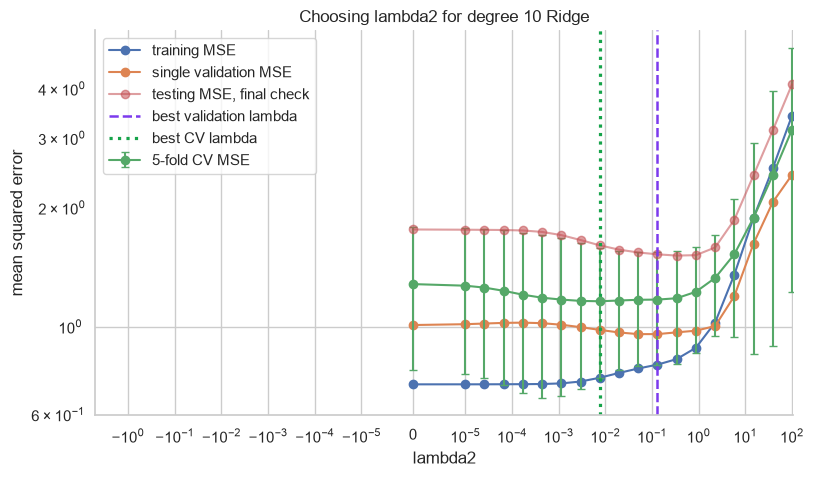

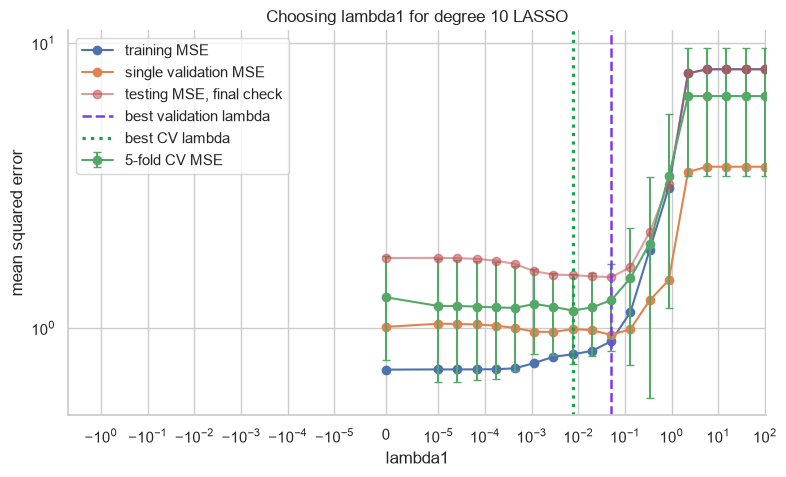

In [12]:
def compare_lambda_selection(method, degree=MAX_HYPOTHESIS_DEGREE, lambda_values=None, n_splits=5):
    if lambda_values is None:
        lambda_values = np.r_[0.0, np.logspace(-5, 2, 18)]

    rows = []
    for lam in lambda_values:
        if method == "Ridge":
            lambda1, lambda2 = 0.0, lam
            lambda_name = "lambda2"
        elif method == "LASSO":
            lambda1, lambda2 = lam, 0.0
            lambda_name = "lambda1"
        else:
            raise ValueError("Use Ridge or LASSO for this comparison.")

        holdout = fit_polynomial_model(degree, method, lambda1=lambda1, lambda2=lambda2)
        cv = cross_validate_polynomial_model(degree, method, lambda1=lambda1, lambda2=lambda2, n_splits=n_splits)
        rows.append({
            "method": method,
            "degree": degree,
            "lambda": lam,
            lambda_name: lam,
            "train_mse": holdout["train_mse"],
            "validation_mse": holdout["validation_mse"],
            "cv_mean_mse": cv["cv_mean_mse"],
            "cv_std_mse": cv["cv_std_mse"],
            "test_mse": holdout["test_mse"],
            "nonzero_coefficients": holdout["nonzero_coefficients"],
        })

    return pd.DataFrame(rows)

ridge_lambda_selection = compare_lambda_selection("Ridge")
lasso_lambda_selection = compare_lambda_selection("LASSO")

best_ridge_holdout = ridge_lambda_selection.loc[ridge_lambda_selection["validation_mse"].idxmin()]
best_ridge_cv = ridge_lambda_selection.loc[ridge_lambda_selection["cv_mean_mse"].idxmin()]
best_lasso_holdout = lasso_lambda_selection.loc[lasso_lambda_selection["validation_mse"].idxmin()]
best_lasso_cv = lasso_lambda_selection.loc[lasso_lambda_selection["cv_mean_mse"].idxmin()]

summary = pd.DataFrame([
    {"method": "Ridge", "selection rule": "best validation MSE", **best_ridge_holdout.to_dict()},
    {"method": "Ridge", "selection rule": "best cross-validation MSE", **best_ridge_cv.to_dict()},
    {"method": "LASSO", "selection rule": "best validation MSE", **best_lasso_holdout.to_dict()},
    {"method": "LASSO", "selection rule": "best cross-validation MSE", **best_lasso_cv.to_dict()},
])

display(summary[[
    "method", "selection rule", "degree", "lambda", "train_mse", "validation_mse", "cv_mean_mse", "cv_std_mse", "test_mse", "nonzero_coefficients"
]].style.format({
    "lambda": "{:.1e}",
    "train_mse": "{:.3f}",
    "validation_mse": "{:.3f}",
    "cv_mean_mse": "{:.3f}",
    "cv_std_mse": "{:.3f}",
    "test_mse": "{:.3f}",
}))


def plot_lambda_selection(selection_df, method, lambda_label):
    fig, ax = plt.subplots(figsize=(9, 5))
    x = selection_df["lambda"]
    ax.plot(x, selection_df["train_mse"], marker="o", label="training MSE")
    ax.plot(x, selection_df["validation_mse"], marker="o", label="single validation MSE")
    ax.errorbar(
        x,
        selection_df["cv_mean_mse"],
        yerr=selection_df["cv_std_mse"],
        marker="o",
        capsize=3,
        label="5-fold CV MSE",
    )
    ax.plot(x, selection_df["test_mse"], marker="o", alpha=0.55, label="testing MSE, final check")

    best_holdout = selection_df.loc[selection_df["validation_mse"].idxmin()]
    best_cv = selection_df.loc[selection_df["cv_mean_mse"].idxmin()]
    ax.axvline(best_holdout["lambda"], color="#7c3aed", linestyle="--", linewidth=1.8, label="best validation lambda")
    ax.axvline(best_cv["lambda"], color="#16a34a", linestyle=":", linewidth=2.3, label="best CV lambda")

    ax.set_xscale("symlog", linthresh=1e-5)
    ax.set_yscale("log")
    ax.set_title(f"Choosing {lambda_label} for degree {MAX_HYPOTHESIS_DEGREE} {method}")
    ax.set_xlabel(lambda_label)
    ax.set_ylabel("mean squared error")
    ax.legend()
    plt.show()

plot_lambda_selection(ridge_lambda_selection, "Ridge", "lambda2")
plot_lambda_selection(lasso_lambda_selection, "LASSO", "lambda1")